# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.2 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 2.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 4.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 3.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 3.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 2.5 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 3.5 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.7/676.7 kB 4.3 

## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [3]:
# YOUR CODE HERE
import glob
from datasets import load_dataset

policy_files = glob.glob("Dataset/sop_documents/*.md")
print(f"Found {len(policy_files)} policy files:")
for f in policy_files:
    print("  -", f)


dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")

df = dataset["train"].to_pandas()

print("\nDataset shape (rows, columns):", df.shape)
df.info()

Found 13 policy files:
  - Dataset/sop_documents/account_recovery.md
  - Dataset/sop_documents/billing_disputes.md
  - Dataset/sop_documents/escalation_matrix.md
  - Dataset/sop_documents/technical_troubleshooting.md
  - Dataset/sop_documents/shipping_delays.md
  - Dataset/sop_documents/order_tracking.md
  - Dataset/sop_documents/subscription_cancellation.md
  - Dataset/sop_documents/data_privacy.md
  - Dataset/sop_documents/working_hours.md
  - Dataset/sop_documents/refund_policy.md
  - Dataset/sop_documents/payment_methods.md
  - Dataset/sop_documents/product_return.md
  - Dataset/sop_documents/password_reset.md

Dataset shape (rows, columns): (26872, 5)
<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str 

In [8]:
df.head()
df.sample(5, random_state=42)
df[["instruction", "category", "intent"]].head(10)

df.to_csv("bitext_full_raw.csv", index=False)
print(len(df))

26872


#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [9]:
# YOUR CODE HERE
print("Total rows:", len(df))

print("Unique intents:", df["intent"].nunique())
print("\nList of intents:")
print(df["intent"].unique())

df_sample = df.sample(4000, random_state=42).reset_index(drop=True)

print("\nSampled dataset shape:", df_sample.shape)

Total rows: 26872
Unique intents: 27

List of intents:
<ArrowStringArray>
[            'cancel_order',             'change_order',
  'change_shipping_address',   'check_cancellation_fee',
            'check_invoice',    'check_payment_methods',
      'check_refund_policy',                'complaint',
 'contact_customer_service',      'contact_human_agent',
           'create_account',           'delete_account',
         'delivery_options',          'delivery_period',
             'edit_account',              'get_invoice',
               'get_refund',  'newsletter_subscription',
            'payment_issue',              'place_order',
         'recover_password',    'registration_problems',
                   'review',  'set_up_shipping_address',
           'switch_account',              'track_order',
             'track_refund']
Length: 27, dtype: str

Sampled dataset shape: (4000, 5)


#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [14]:
# YOUR CODE HERE
print("Null values per column:")
print(df_sample.isnull().sum())

print("\nRows before cleaning:", len(df_sample))

df_sample["instruction_norm"] = df_sample["instruction"].str.lower().str.strip()
df_sample = df_sample.drop_duplicates(subset="instruction_norm").reset_index(drop=True)
df_sample = df_sample.drop(columns="instruction_norm")

print("Rows after cleaning:", len(df_sample))
print("Duplicates removed:", 4000 - len(df_sample))

Null values per column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Rows before cleaning: 3902
Rows after cleaning: 3902
Duplicates removed: 98


### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

Matplotlib is building the font cache; this may take a moment.


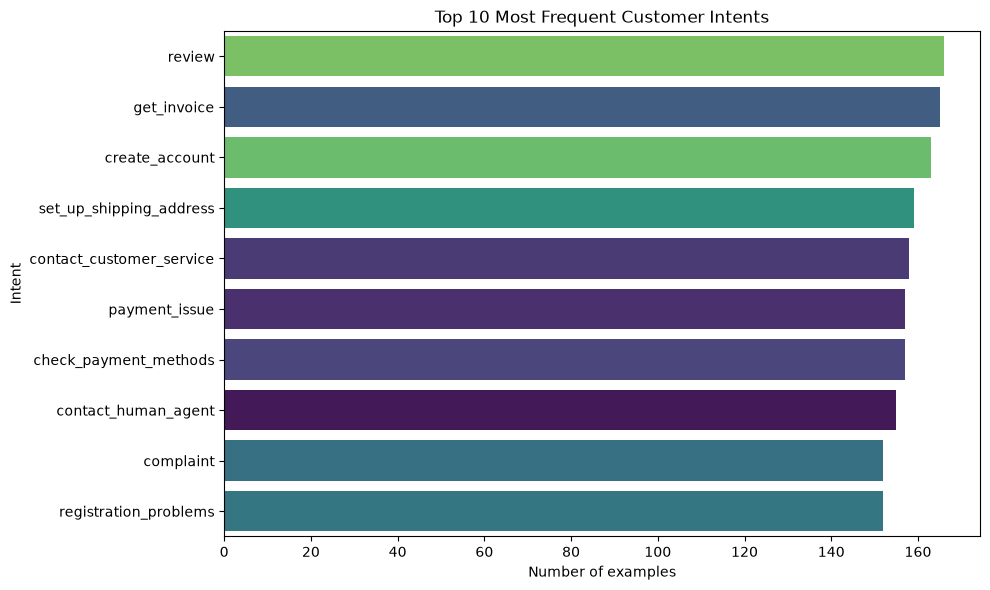

In [15]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import seaborn as sns

top10 = df_sample["intent"].value_counts().index[:10]

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_sample,
    y="intent",
    order=top10,
    hue="intent",
    palette="viridis",
    legend=False
)
plt.title("Top 10 Most Frequent Customer Intents")
plt.xlabel("Number of examples")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [ ]:
# YOUR CODE HERE
from sklearn.feature_extraction.text import TfidfVectorizer

doc_texts = []
doc_names = []
for f in sorted(policy_files):
    with open(f, "r") as file:
        doc_texts.append(file.read())
    doc_names.append(f.split("/")[-1])

print("Loaded", len(doc_texts), "documents")

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(doc_texts)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

Loaded 13 documents
TF-IDF matrix shape: (13, 797)


In [17]:
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),         
    index=doc_names,              
    columns=vectorizer.get_feature_names_out()
)

print("Shape:", tfidf_df.shape)
tfidf_df.head()

Shape: (13, 797)


,00,08,10,12,18,20,21,24,30,48,60,acceptable,accepted,accepts,access,accidental,account,accounts,acknowledge,act,action,actioned,actions,active,actually,add,address,addresses,advise,advising,affect,affects,agent,agents,alias,allow,allowing,alternative,amounts,answerable,...,update,updated,updates,updating,upper,use,used,users,using,valid,value,vehicle,verification,verified,verify,version,visible,vs,vulnerable,wait,waivers,wallet,wallets,want,wants,warehouse,warranty,weather,weekend,weekends,whichever,widespread,window,workflow,working,writing,written,wrong,zone,zones
account_recovery.md,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.063737,0.0,0.0,0.0,0.0,0.0,0.104530,0.0,0.203967,0.071876,0.0,0.0,0.057423,0.0,0.000000,0.063737,0.0,0.0,0.156795,0.083348,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.052265,0.000000,0.0,0.0,0.0,0.104530,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.143752,0.063737,0.081587,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.071876,0.0,0.000000,0.0,0.0,0.0,0.0
billing_disputes.md,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.042251,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.072741,0.000000,0.0,0.000000,0.0,0.0,0.074444,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.054132,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.042251,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
data_privacy.md,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.204446,0.0,0.095743,0.000000,0.0,0.0,0.044925,0.0,0.000000,0.000000,0.0,0.0,0.040889,0.000000,0.0,0.0,0.065206,0.0,0.027473,0.056232,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.056232,0.0,0.0,0.0,0.040889,0.056232,0.0,0.049864,0.0,0.000000,0.000000,0.112463,0.049864,0.063829,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.040889,0.112463,0.0,0.065206,0.0,0.0,0.0,0.0
escalation_matrix.md,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.085382,0.000000,0.0,0.0,0.000000,0.0,0.087225,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.073499,0.075220,0.0,0.000000,0.0,0.0,0.075220,0.087225,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.066702,0.000000,0.000000,0.066702,0.000000,0.0,0.0,0.0,0.087225,0.07522,0.087225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.087225,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
order_tracking.md,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.121325,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.109307,0.0,0.000000,0.000000,0.0,0.0,0.198976,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.079327,0.0,0.0,0.000000,0.000000,...,0.049744,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.079327,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.049744,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

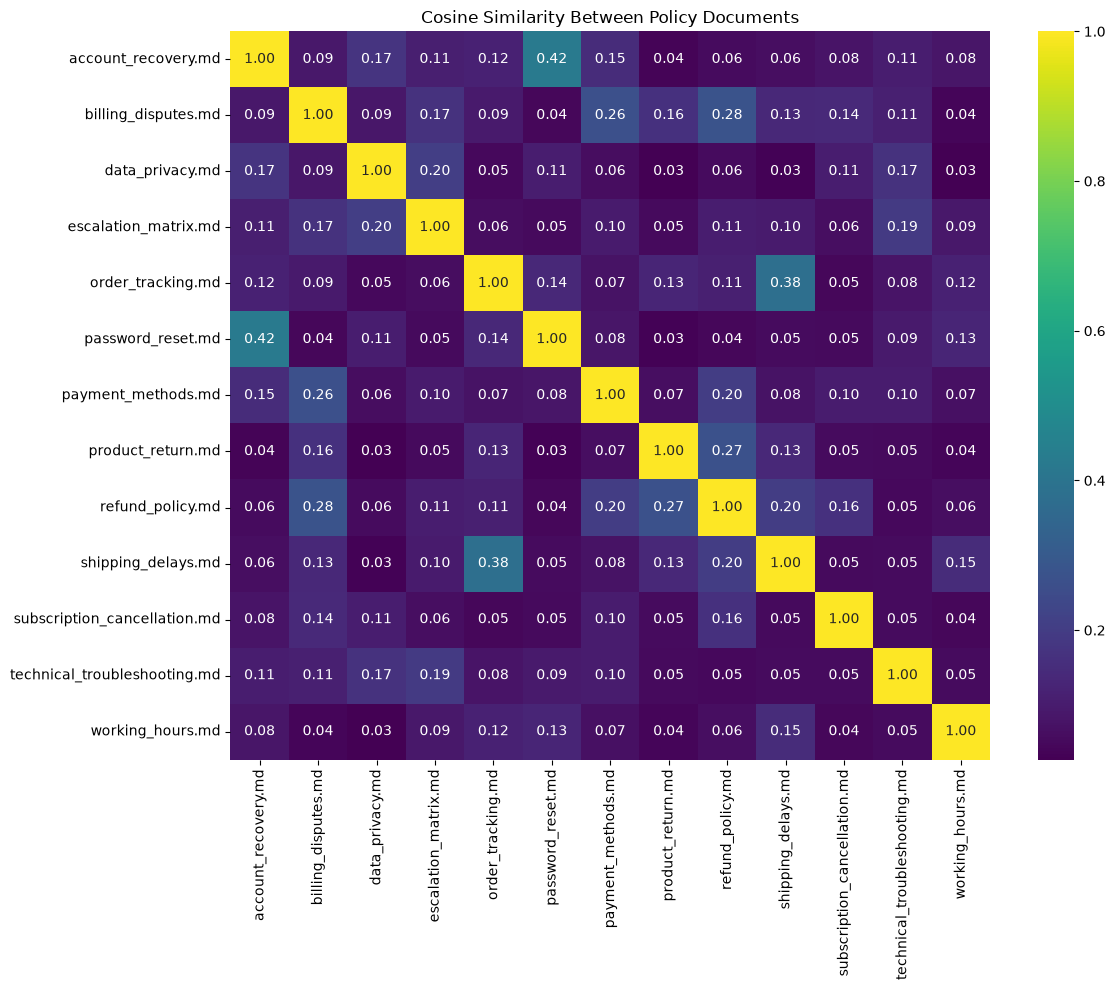

In [18]:
# YOUR CODE HERE
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_matrix,
    xticklabels=doc_names,
    yticklabels=doc_names,
    annot=True,        
    fmt=".2f",         
    cmap="viridis"
)
plt.title("Cosine Similarity Between Policy Documents")
plt.tight_layout()
plt.show()

---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [20]:
# YOUR CODE HERE
df_sample.to_csv("sampled_data.csv", index=False)

print("   Saved sampled_data.csv")
print("   Rows:", len(df_sample))
print("   Columns:", list(df_sample.columns))

   Saved sampled_data.csv
   Rows: 3902
   Columns: ['flags', 'instruction', 'category', 'intent', 'response']


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [ ] Bitext dataset loaded and `.info()` printed
- [ ] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [ ] Nulls inspected, near-duplicates removed via normalised dedup
- [ ] Top 10 intent bar chart rendered
- [ ] TF-IDF vectorisation completed on SOP documents
- [ ] Cosine similarity heatmap rendered
- [ ] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [ ] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**